In [1]:
import pandas as pd
import numpy as np
import shap

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    roc_auc_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

from imblearn.over_sampling import SMOTE

In [2]:
data = pd.read_csv(
    r"C:\\Users\\Haarun\\obesity_project\\data\\Obesity_Dataset.tsv",
    sep="\t"
)

In [3]:
print(data.head())

print(data.columns)

print(data.shape)

  DATE ADDED TO CATALOG  PUBMEDID FIRST AUTHOR        DATE            JOURNAL  \
0            2018-11-05  30120429  Schlauch KA  2018-08-17  Int J Obes (Lond)   
1            2018-11-05  30120429  Schlauch KA  2018-08-17  Int J Obes (Lond)   
2            2018-11-05  30120429  Schlauch KA  2018-08-17  Int J Obes (Lond)   
3            2018-11-05  30120429  Schlauch KA  2018-08-17  Int J Obes (Lond)   
4            2018-11-05  30120429  Schlauch KA  2018-08-17  Int J Obes (Lond)   

                                   LINK  \
0  www.ncbi.nlm.nih.gov/pubmed/30120429   
1  www.ncbi.nlm.nih.gov/pubmed/30120429   
2  www.ncbi.nlm.nih.gov/pubmed/30120429   
3  www.ncbi.nlm.nih.gov/pubmed/30120429   
4  www.ncbi.nlm.nih.gov/pubmed/30120429   

                                               STUDY  \
0  Single-nucleotide polymorphisms in a cohort of...   
1  Single-nucleotide polymorphisms in a cohort of...   
2  Single-nucleotide polymorphisms in a cohort of...   
3  Single-nucleotide polymorph

In [4]:
data["Target"] = data["P-VALUE"].apply(
    lambda x: 1 if x < 1e-6 else 0
)
print(data["Target"].value_counts())

Target
1    1426
0     115
Name: count, dtype: int64


In [5]:
features = [
    "CHR_ID",
    "CHR_POS",
    "REPORTED GENE(S)",
    "MAPPED_GENE",
    "RISK ALLELE FREQUENCY",
    "OR or BETA",
    "STRONGEST SNP-RISK ALLELE",
    "SNPS",
    "CONTEXT",
    "INTERGENIC",
    "UPSTREAM_GENE_DISTANCE",
    "DOWNSTREAM_GENE_DISTANCE"
]

X = data[features]

y = data["Target"]

In [6]:
X = X.fillna("Unknown")

In [7]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

categorical_columns = [
    "REPORTED GENE(S)",
    "MAPPED_GENE",
    "STRONGEST SNP-RISK ALLELE",
    "SNPS",
    "CONTEXT",
    "INTERGENIC"
]

for col in categorical_columns:
    X[col] = label_encoder.fit_transform(
        X[col].astype(str)
    )

In [8]:
numeric_columns = [
    "CHR_ID",
    "CHR_POS",
    "RISK ALLELE FREQUENCY",
    "OR or BETA",
    "UPSTREAM_GENE_DISTANCE",
    "DOWNSTREAM_GENE_DISTANCE"
]

for col in numeric_columns:
    X[col] = pd.to_numeric(
        X[col],
        errors="coerce"
    )

X = X.fillna(0)

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

In [11]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

In [12]:
print(y_train_smote.value_counts())

Target
1    1139
0    1139
Name: count, dtype: int64


In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    roc_auc_score
)

lr = LogisticRegression(
    class_weight='balanced',
    random_state=42,
    max_iter=1000
)

lr.fit(X_train_smote, y_train_smote)

y_pred_lr = lr.predict(X_test)

print("===== LOGISTIC REGRESSION RESULTS =====")

print("Accuracy:", accuracy_score(y_test, y_pred_lr))

print(classification_report(y_test, y_pred_lr))

y_prob_lr = lr.predict_proba(X_test)[:, 1]

print("ROC-AUC:", roc_auc_score(y_test, y_prob_lr))

===== LOGISTIC REGRESSION RESULTS =====
Accuracy: 0.8317152103559871
              precision    recall  f1-score   support

           0       0.25      0.68      0.37        22
           1       0.97      0.84      0.90       287

    accuracy                           0.83       309
   macro avg       0.61      0.76      0.63       309
weighted avg       0.92      0.83      0.86       309

ROC-AUC: 0.8774152676591701


In [14]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)

rf.fit(X_train_smote, y_train_smote)

y_pred_rf = rf.predict(X_test)

print("===== RANDOM FOREST RESULTS =====")

print("Accuracy:", accuracy_score(y_test, y_pred_rf))

print(classification_report(y_test, y_pred_rf))

y_prob_rf = rf.predict_proba(X_test)[:, 1]

print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

===== RANDOM FOREST RESULTS =====
Accuracy: 0.9158576051779935
              precision    recall  f1-score   support

           0       0.44      0.64      0.52        22
           1       0.97      0.94      0.95       287

    accuracy                           0.92       309
   macro avg       0.70      0.79      0.74       309
weighted avg       0.93      0.92      0.92       309

ROC-AUC: 0.9290465631929047


In [15]:
from sklearn.svm import SVC

svm_model = SVC(
    probability=True,
    class_weight='balanced',
    random_state=42
)

svm_model.fit(X_train_smote, y_train_smote)

y_pred_svm = svm_model.predict(X_test)

print("===== SVM RESULTS =====")

print("Accuracy:", accuracy_score(y_test, y_pred_svm))

print(classification_report(y_test, y_pred_svm))

y_prob_svm = svm_model.predict_proba(X_test)[:, 1]

print("ROC-AUC:", roc_auc_score(y_test, y_prob_svm))

===== SVM RESULTS =====
Accuracy: 0.8478964401294499
              precision    recall  f1-score   support

           0       0.27      0.68      0.39        22
           1       0.97      0.86      0.91       287

    accuracy                           0.85       309
   macro avg       0.62      0.77      0.65       309
weighted avg       0.92      0.85      0.88       309

ROC-AUC: 0.8995882166613874


In [16]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    max_iter=500,
    random_state=42
)

mlp.fit(X_train_smote, y_train_smote)

y_pred_mlp = mlp.predict(X_test)

print("===== MLP RESULTS =====")

print("Accuracy:", accuracy_score(y_test, y_pred_mlp))

print(classification_report(y_test, y_pred_mlp))

y_prob_mlp = mlp.predict_proba(X_test)[:, 1]

print("ROC-AUC:", roc_auc_score(y_test, y_prob_mlp))

===== MLP RESULTS =====
Accuracy: 0.9093851132686084
              precision    recall  f1-score   support

           0       0.38      0.45      0.42        22
           1       0.96      0.94      0.95       287

    accuracy                           0.91       309
   macro avg       0.67      0.70      0.68       309
weighted avg       0.92      0.91      0.91       309

ROC-AUC: 0.8699714919227115


In [17]:
import shap

explainer = shap.TreeExplainer(rf)

shap_values = explainer.shap_values(X_test)

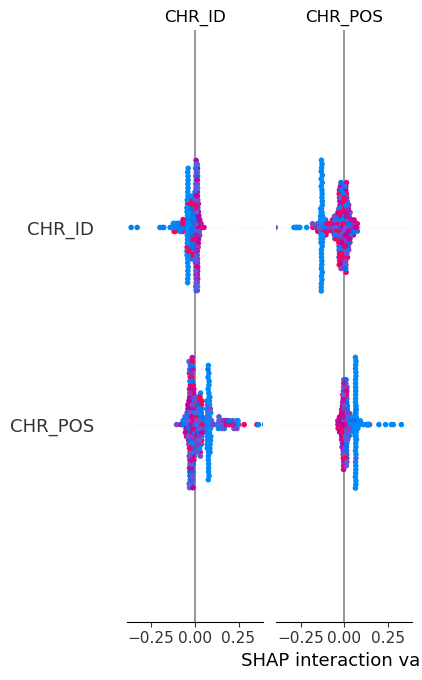

In [18]:
shap.summary_plot(
    shap_values,
    X_test,
    feature_names=features
)

In [19]:
from xgboost import XGBClassifier

In [20]:
xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train_smote, y_train_smote)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [21]:
y_pred_xgb = xgb.predict(X_test)

y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

In [22]:
print("===== XGBOOST RESULTS =====")

print("Accuracy:", accuracy_score(y_test, y_pred_xgb))

print(classification_report(y_test, y_pred_xgb))

print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))

===== XGBOOST RESULTS =====
Accuracy: 0.9029126213592233
              precision    recall  f1-score   support

           0       0.38      0.59      0.46        22
           1       0.97      0.93      0.95       287

    accuracy                           0.90       309
   macro avg       0.67      0.76      0.71       309
weighted avg       0.93      0.90      0.91       309

ROC-AUC: 0.9309471016788091


In [23]:
explainer_xgb = shap.TreeExplainer(xgb)

shap_values_xgb = explainer_xgb.shap_values(X_test)

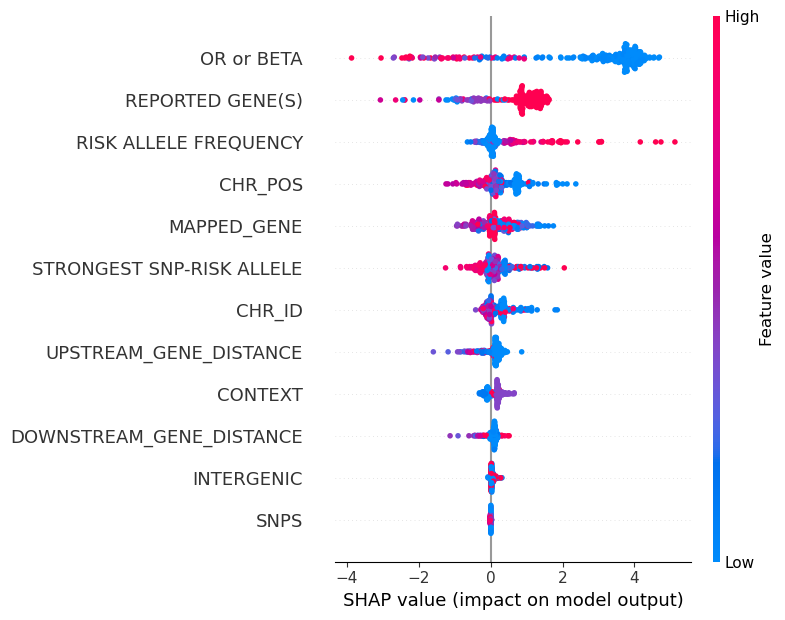

In [24]:
shap.summary_plot(
    shap_values_xgb,
    X_test,
    feature_names=features
)